This notebook is a demo for the local Chan-Vese segmentation method for various kinds of images.

Copyright (c) 2025 Kevin Bui <kevinb3@uci.edu> and Adina Ciomaga <adina@math.univ-paris-diderot.fr>
 
This program is free software: you can redistribute it and/or modify it under the terms of the GNU Affero General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along
with this program. If not, see <http://www.gnu.org/licenses/>.

In [1]:
# import packages
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from skimage import segmentation
from lcv import *
from utils import *


In [2]:
# load image
map = Image.open('./images/grayscale_two_phase/map.png')
map = np.array(map)/255

# set seed
np.random.seed(9999)

# add noise
noise = np.random.normal(0, 0.05, map.shape)
noisy_map = np.clip(map+noise,0,1)
noisy_map = rescale_image(noisy_map)

# draw rectangle around close-up region
x1, y1 = 150, 70
x2,y2 = 200, 120

# Parameter: Lambda

Number of iterations completed: 24 

Energy: 3381717.6183318044 
 

Number of iterations completed: 26 

Energy: 4674402.624781051 
 

Number of iterations completed: 22 

Energy: 6252918.587610882 
 



(np.float64(-0.5), np.float64(50.5), np.float64(50.5), np.float64(-0.5))

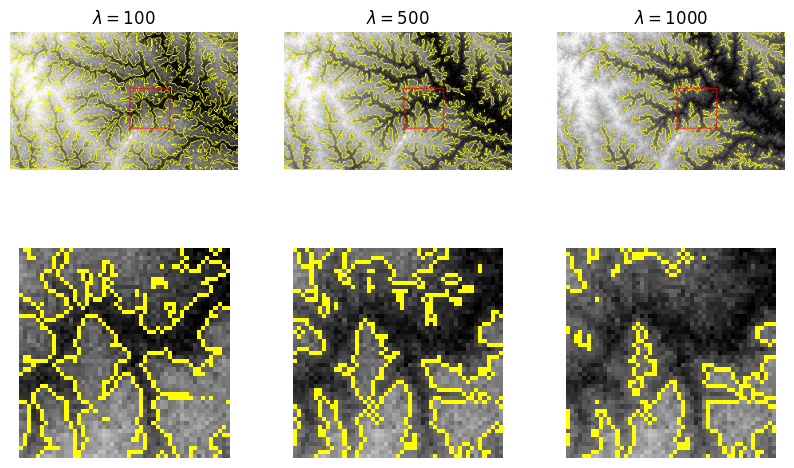

In [3]:
# lambda = 100
result_lambda100 = localtwophase(noisy_map, 100, 10000, 20)
result_lambda100_edge = segmentation.mark_boundaries(noisy_map, result_lambda100.astype(int))
result_lambda100_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_lambda100[y1:(y2+1), x1:(x2+1)].astype(int))



# lambda = 500
result_lambda500 = localtwophase(noisy_map, 500, 10000, 20)
result_lambda500_edge = segmentation.mark_boundaries(noisy_map, result_lambda500.astype(int))
result_lambda500_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_lambda500[y1:(y2+1), x1:(x2+1)].astype(int))


# lambda = 1000
result_lambda1000 = localtwophase(noisy_map, 1000, 10000, 20)
result_lambda1000_edge = segmentation.mark_boundaries(noisy_map, result_lambda1000.astype(int))
result_lambda1000_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_lambda1000[y1:(y2+1), x1:(x2+1)].astype(int))



result_lambda100_edge = Image.fromarray(np.uint8(result_lambda100_edge*255))
draw = ImageDraw.Draw(result_lambda100_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda500_edge = Image.fromarray(np.uint8(result_lambda500_edge*255))
draw = ImageDraw.Draw(result_lambda500_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda1000_edge = Image.fromarray(np.uint8(result_lambda1000_edge*255))
draw = ImageDraw.Draw(result_lambda1000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_lambda100_edge)
plt.axis('off')
plt.title(r'$\lambda =100$')
plt.subplot(2,3,4)
plt.imshow(result_lambda100_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_lambda500_edge)
plt.axis('off')
plt.title(r'$\lambda =500$')
plt.subplot(2,3,5)
plt.imshow(result_lambda500_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_lambda1000_edge)
plt.axis('off')
plt.title(r'$\lambda =1000$')
plt.subplot(2,3,6)
plt.imshow(result_lambda1000_edge2)
plt.axis('off')

# Parameter: Beta

Number of iterations completed: 14 

Energy: 314226.7547523655 
 

Number of iterations completed: 23 

Energy: 630421.2786193865 
 

Number of iterations completed: 24 

Energy: 3381717.6183318044 
 



(np.float64(-0.5), np.float64(50.5), np.float64(50.5), np.float64(-0.5))

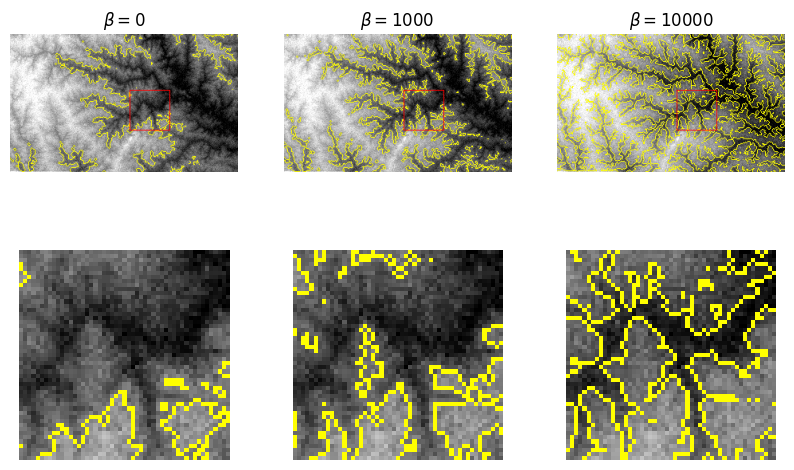

In [4]:
# beta = 0 
result_beta0 = localtwophase(noisy_map, 100, 0, 20)
result_beta0_edge = segmentation.mark_boundaries(noisy_map, result_beta0.astype(int))
result_beta0_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_beta0[y1:(y2+1), x1:(x2+1)].astype(int))


# beta = 1000
result_beta1000 = localtwophase(noisy_map, 100, 1000, 20)
result_beta1000_edge = segmentation.mark_boundaries(noisy_map, result_beta1000.astype(int))
result_beta1000_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_beta1000[y1:(y2+1), x1:(x2+1)].astype(int))


# beta = 10000
result_beta10000 = localtwophase(noisy_map, 100, 10000, 20)
result_beta10000_edge = segmentation.mark_boundaries(noisy_map, result_beta10000.astype(int))
result_beta10000_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_beta10000[y1:(y2+1), x1:(x2+1)].astype(int))


result_beta0_edge = Image.fromarray(np.uint8(result_beta0_edge*255))
draw = ImageDraw.Draw(result_beta0_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta1000_edge = Image.fromarray(np.uint8(result_beta1000_edge*255))
draw = ImageDraw.Draw(result_beta1000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta10000_edge = Image.fromarray(np.uint8(result_beta10000_edge*255))
draw = ImageDraw.Draw(result_beta10000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_beta0_edge)
plt.axis('off')
plt.title(r'$\beta =0$')
plt.subplot(2,3,4)
plt.imshow(result_beta0_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_beta1000_edge)
plt.axis('off')
plt.title(r'$\beta =1000$')
plt.subplot(2,3,5)
plt.imshow(result_beta1000_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_beta10000_edge)
plt.axis('off')
plt.title(r'$\beta =10000$')
plt.subplot(2,3,6)
plt.imshow(result_beta10000_edge2)
plt.axis('off')

# Parameter: dt

Number of iterations completed: 19 

Energy: 3372042.581555765 
 

Number of iterations completed: 24 

Energy: 3381717.6183318044 
 

Number of iterations completed: 37 

Energy: 3411260.5195777835 
 



(np.float64(-0.5), np.float64(50.5), np.float64(50.5), np.float64(-0.5))

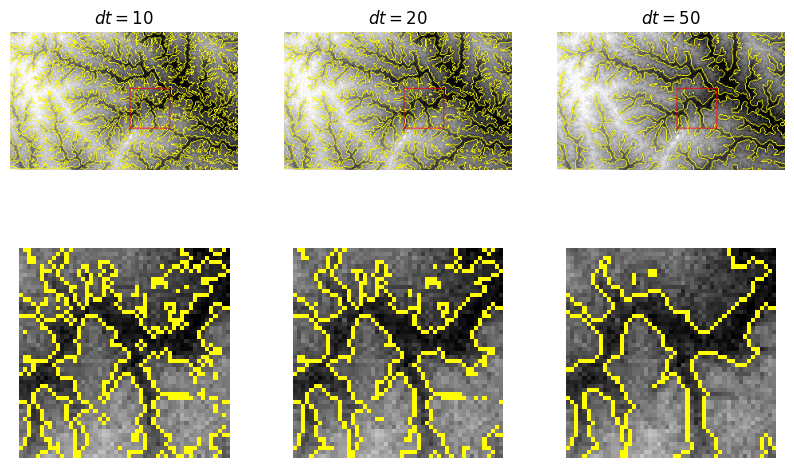

In [5]:
# dt = 10 
result_dt10 = localtwophase(noisy_map, 100, 10000, 10)
result_dt10_edge = segmentation.mark_boundaries(noisy_map, result_dt10.astype(int))
result_dt10_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_dt10[y1:(y2+1), x1:(x2+1)].astype(int))


# dt = 20
result_dt20 = localtwophase(noisy_map, 100, 10000, 20)
result_dt20_edge = segmentation.mark_boundaries(noisy_map, result_dt20.astype(int))
result_dt20_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_dt20[y1:(y2+1), x1:(x2+1)].astype(int))


# dt = 100
result_dt100 = localtwophase(noisy_map, 100, 10000, 100)
result_dt100_edge = segmentation.mark_boundaries(noisy_map, result_dt100.astype(int))
result_dt100_edge2 = segmentation.mark_boundaries(noisy_map[y1:(y2+1), x1:(x2+1)], result_dt100[y1:(y2+1), x1:(x2+1)].astype(int))


result_dt10_edge = Image.fromarray(np.uint8(result_dt10_edge*255))
draw = ImageDraw.Draw(result_dt10_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt20_edge = Image.fromarray(np.uint8(result_dt20_edge*255))
draw = ImageDraw.Draw(result_dt20_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt100_edge = Image.fromarray(np.uint8(result_dt100_edge*255))
draw = ImageDraw.Draw(result_dt100_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_dt10_edge)
plt.axis('off')
plt.title(r'$dt =10$')
plt.subplot(2,3,4)
plt.imshow(result_dt10_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_dt20_edge)
plt.axis('off')
plt.title(r'$dt = 20$')
plt.subplot(2,3,5)
plt.imshow(result_dt20_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_dt100_edge)
plt.axis('off')
plt.title(r'$dt=50$')
plt.subplot(2,3,6)
plt.imshow(result_dt100_edge2)
plt.axis('off')